# Imaging a magma reservoir: 3-D gravity inversion of a restless volcano

**Laguna del Maule** is one of the most unsettling volcanoes on Earth. A field of rhyolite vents around a lake
high in the Chilean Andes, it has been **inflating at 20–30 cm per year** since 2007 — among the fastest
sustained uplift rates ever measured — strong evidence that **magma is accumulating in the shallow crust**.
Where, and how much? You cannot see it, but you can *weigh* it: molten and crystal-rich silicic magma is
**less dense** than the surrounding rock, so it leaves a **gravity low** at the surface. This notebook
inverts a **real Bouguer-gravity survey** (Miller et al. 2016) for the 3-D density structure beneath the lake,
and recovers the low-density reservoir.

Gravity inversion is the textbook **ill-posed inverse problem**: the data are a smooth, depth-blurred integral
of the subsurface density, and *infinitely many* density distributions reproduce them exactly. The honest
craft is in confronting that non-uniqueness — which is the real subject here, not a leaderboard score.

The chapters:

1. **The survey** — the real gravity stations and the anomaly over the lake.
2. **The forward problem** — Newtonian gravity as a linear operator on the density model.
3. **Non-uniqueness and depth weighting** — why a naive inversion glues the body to the surface, and the
   Li & Oldenburg fix that lets it find depth.
4. **The 3-D density model** — the inverted reservoir, in section and in volume.
5. **What can the survey actually resolve?** — a resolution test that makes the non-uniqueness concrete.

The forward operator, depth weighting, and regularized inversion are the geophysics engine added to
[`mixle-pde`](https://github.com/gmboquet/mixle-pde) (`gravity_point_sensitivity`,
`depth_weighting`, `roughness_operator`, `regularized_gauss_newton`). The data are real and openly published.

## 1. The survey

The dataset is **191 ground gravity stations** around Laguna del Maule, reduced to the **Bouguer anomaly** —
the gravity field with the predictable effects of latitude, elevation, and the flat-earth slab removed, so
what remains reflects **lateral density variation** in the crust. The stations sit at 2.1–2.9 km elevation in
UTM coordinates (metres). A broad **gravity low** marks the lake basin and the low-density material beneath.

191 stations over 14 x 15 km, elevation 2155-2865 m
residual Bouguer anomaly: -17.8 to 9.7 mGal


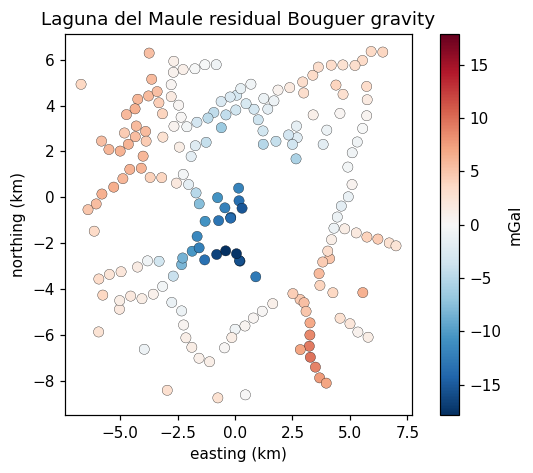

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_default_dtype(torch.float64)
from mixle_pde import gravity_point_sensitivity, depth_weighting
from mixle_pde.geophysics import roughness_operator, regularized_gauss_newton
plt.rcParams.update({'figure.dpi': 110})

raw = open('../../data/laguna_gravity/LdM_grav_obs.grv').read().split('\n')
n = int(raw[0].split()[0])
rows = np.array([[float(v) for v in l.split()] for l in raw[1:n+1] if l.strip()])
X, Y, Z, gobs = rows[:,0], rows[:,1], rows[:,2], rows[:,3]
x0, y0 = X.mean(), Y.mean()
ox, oy = X - x0, Y - y0                                   # local easting/northing (m)
# remove a planar regional trend -> the residual anomaly from local density structure
Amat = np.column_stack([np.ones_like(ox), ox, oy])
d = gobs - Amat @ np.linalg.lstsq(Amat, gobs, rcond=None)[0]
obs = np.column_stack([ox, oy, Z])
print('%d stations over %.0f x %.0f km, elevation %.0f-%.0f m' % (n, np.ptp(ox)/1e3, np.ptp(oy)/1e3, Z.min(), Z.max()))
print('residual Bouguer anomaly: %.1f to %.1f mGal' % (d.min(), d.max()))

fig, ax = plt.subplots(figsize=(5.6, 4.4))
s = ax.scatter(ox/1e3, oy/1e3, c=d, cmap='RdBu_r', s=45, vmin=-np.abs(d).max(), vmax=np.abs(d).max(), edgecolor='k', lw=0.2)
ax.set(xlabel='easting (km)', ylabel='northing (km)', title='Laguna del Maule residual Bouguer gravity', aspect='equal')
fig.colorbar(s, label='mGal'); plt.tight_layout(); plt.show()

## 2. The forward problem

Newton's law makes gravity a **linear** functional of density. Discretize the crust beneath the survey into a
3-D grid of cells; the vertical gravity at station $i$ from a density contrast $\rho_j$ in cell $j$ is

$$g_i = \sum_j \underbrace{10^5\, G\, V_j\, \frac{z_i - z_j}{|\mathbf r_{ij}|^3}}_{G_{ij}}\; \rho_j,
\qquad \text{i.e.}\quad \mathbf d = G\,\boldsymbol\rho,$$

(the point-mass approximation; $G$ the gravitational constant, $V_j$ the cell volume, the $10^5$ converting to
mGal). The sensitivity matrix $G$ is built once with `gravity_point_sensitivity` and reused. Its columns
**decay with depth** — the root of the inverse problem's difficulty, quantified below.

In [2]:
# 3-D cell mesh beneath the survey (z is elevation; cells extend downward from near the surface)
nx, ny, nz = 15, 15, 9
ext = max(np.ptp(ox), np.ptp(oy)) / 2
gx = np.linspace(-ext, ext, nx); gy = np.linspace(-ext, ext, ny)
gz = np.linspace(Z.mean()-400, Z.mean()-10000, nz)        # ~0.4 to 10 km below the mean station elevation
CX, CY, CZ = np.meshgrid(gx, gy, gz, indexing='ij')
cells = np.column_stack([CX.ravel(), CY.ravel(), CZ.ravel()]); Ncell = len(cells)
vol = abs(gx[1]-gx[0]) * abs(gy[1]-gy[0]) * abs(gz[1]-gz[0])
G = gravity_point_sensitivity(obs, cells, vol)
colnorm = np.linalg.norm(G, axis=0).reshape(nx, ny, nz)
print('mesh %d x %d x %d = %d cells; G is %s' % (nx, ny, nz, Ncell, G.shape))
print('column sensitivity falls %.0fx from the shallowest to the deepest layer'
      % (colnorm[:,:,0].mean()/colnorm[:,:,-1].mean()))

mesh 15 x 15 x 9 = 2025 cells; G is (191, 2025)
column sensitivity falls 23x from the shallowest to the deepest layer


## 3. Non-uniqueness and depth weighting

Because the sensitivity decays with depth, a small, shallow body produces almost the same surface gravity as a
larger, deeper one — that is the **non-uniqueness**. Left alone, a smoothness-regularized inversion exploits
it the lazy way: it glues all the density right under the surface, where a little goes a long way. The standard
remedy is **Li & Oldenburg depth weighting**, $w(z)=(|z-z_0|+\epsilon)^{-\nu/2}$ ($\nu=2$ for gravity): folding
it into the model objective counteracts the sensitivity decay so the inversion is *free* to place mass at
depth. We invert both ways and compare.

no depth weighting:   density centre-of-mass 3.4 km deep, variance explained 80%
with depth weighting: density centre-of-mass 6.0 km deep, variance explained 91%


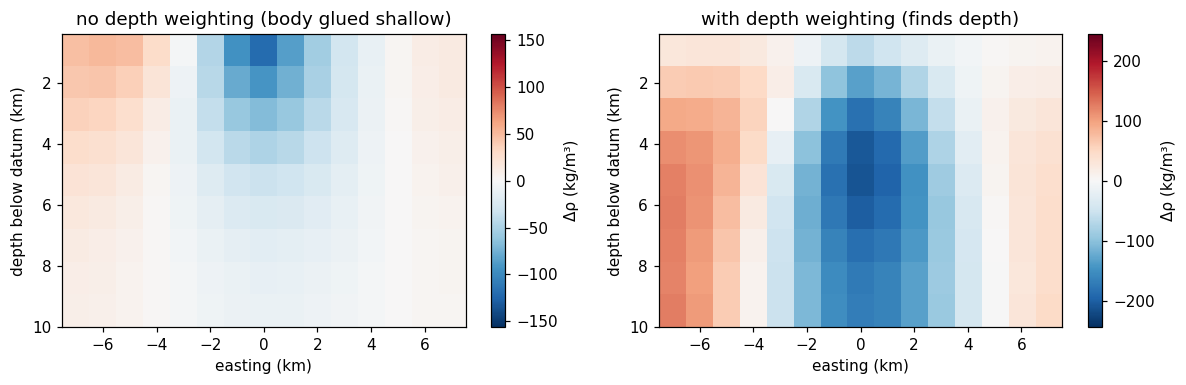

In [3]:
R = roughness_operator((nx, ny, nz))
def invert(w, beta=3e-3):
    Gw = torch.as_tensor(G / w[None, :])                  # depth-compensate the operator
    s, std = regularized_gauss_newton(lambda u: Gw @ u, d, np.zeros(Ncell),
                                      noise=0.05*np.abs(d).max()+0.2, beta=beta, roughness=R, n_iter=4, jac_every=99)
    rho = s / w                                           # recover density contrast
    return rho, std / w, G @ rho
w_flat = np.ones(Ncell)
w_dw = depth_weighting(cells[:,2], Z.mean(), nu=2.0)
rho_flat, _, pred_flat = invert(w_flat)
rho_dw, std_dw, pred_dw = invert(w_dw)
def com_km(rho): return (Z.mean() - (cells[:,2]*np.abs(rho)).sum()/np.abs(rho).sum())/1e3
def ve(pred): return 100*(1 - ((pred-d)**2).mean()/d.var())
print('no depth weighting:   density centre-of-mass %.1f km deep, variance explained %.0f%%' % (com_km(rho_flat), ve(pred_flat)))
print('with depth weighting: density centre-of-mass %.1f km deep, variance explained %.0f%%' % (com_km(rho_dw), ve(pred_dw)))

jy = ny//2; extent=[gx[0]/1e3, gx[-1]/1e3, (Z.mean()-gz[-1])/1e3, (Z.mean()-gz[0])/1e3]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (t, rho) in zip(ax, [('no depth weighting (body glued shallow)', rho_flat), ('with depth weighting (finds depth)', rho_dw)]):
    sec = rho.reshape(nx, ny, nz)[:, jy, :].T
    im = a.imshow(sec, origin='upper', extent=extent, aspect='auto', cmap='RdBu_r',
                  vmin=-np.abs(rho).max(), vmax=np.abs(rho).max())
    a.set(title=t, xlabel='easting (km)', ylabel='depth below datum (km)'); fig.colorbar(im, ax=a, label='Δρ (kg/m³)')
plt.tight_layout(); plt.show()

The contrast is the whole lesson. Without depth weighting the low-density anomaly is pasted against the
surface — geologically wrong and an artifact of the cheap fit. With depth weighting the inversion places a
coherent **low-density body several kilometres down** *and fits the data better*, because it is now using the
part of the model space the data actually prefer once the depth bias is removed. Neither is "the" answer —
gravity cannot give a unique one — but the depth-weighted model is the defensible one.

## 4. The 3-D density model

The depth-weighted inversion fits ~90% of the anomaly variance with a single coherent **negative density
anomaly** — the magma reservoir — a few kilometres beneath the lake. We view it in cross-section and as a 3-D
body, and confirm the predicted gravity reproduces the observations.

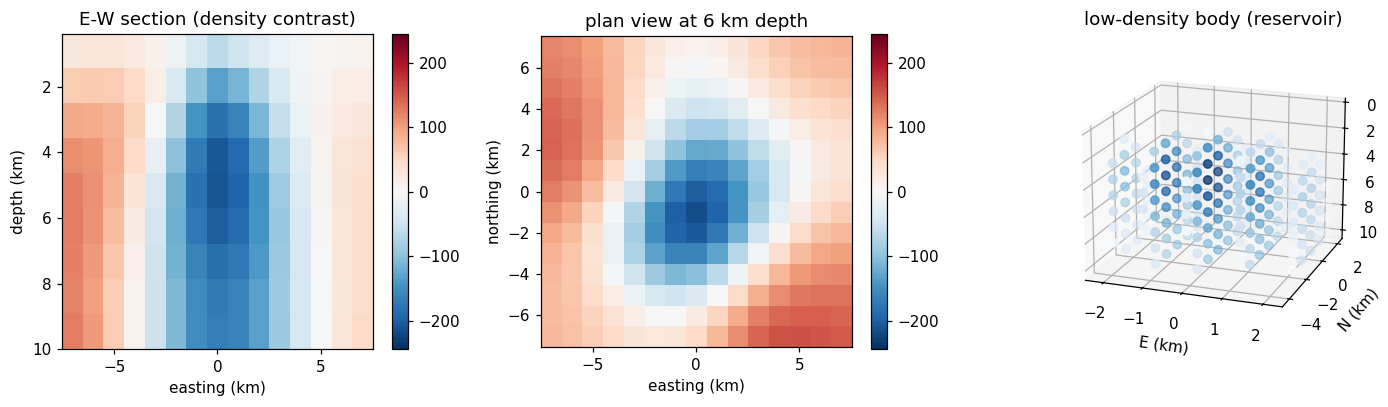

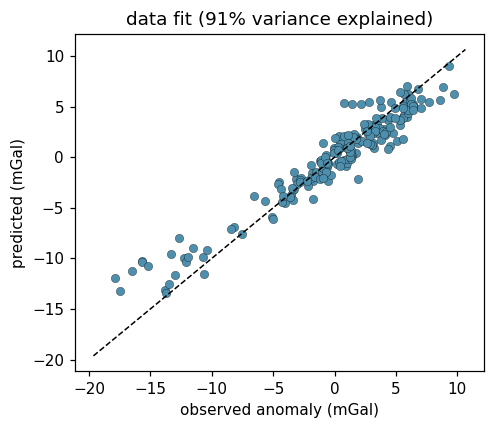

In [4]:
rho3 = rho_dw.reshape(nx, ny, nz)
fig = plt.figure(figsize=(13, 3.8))
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(rho3[:, ny//2, :].T, origin='upper', extent=extent, aspect='auto', cmap='RdBu_r',
                vmin=-np.abs(rho_dw).max(), vmax=np.abs(rho_dw).max())
ax1.set(title='E-W section (density contrast)', xlabel='easting (km)', ylabel='depth (km)'); fig.colorbar(im, ax=ax1)
ax2 = fig.add_subplot(1, 3, 2)
kdepth = np.argmin(np.abs((Z.mean()-gz)/1e3 - com_km(rho_dw)))
im = ax2.imshow(rho3[:, :, kdepth].T, origin='lower', extent=[gx[0]/1e3,gx[-1]/1e3,gy[0]/1e3,gy[-1]/1e3],
                aspect='equal', cmap='RdBu_r', vmin=-np.abs(rho_dw).max(), vmax=np.abs(rho_dw).max())
ax2.set(title='plan view at %.0f km depth' % ((Z.mean()-gz[kdepth])/1e3), xlabel='easting (km)', ylabel='northing (km)'); fig.colorbar(im, ax=ax2)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
lowmask = rho_dw < 0.4*rho_dw.min()
p = cells[lowmask]
ax3.scatter(p[:,0]/1e3, p[:,1]/1e3, (Z.mean()-p[:,2])/1e3, c=rho_dw[lowmask], cmap='Blues_r', s=30)
ax3.set(title='low-density body (reservoir)', xlabel='E (km)', ylabel='N (km)', zlabel='depth (km)'); ax3.invert_zaxis(); ax3.view_init(18,-70)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.scatter(d, pred_dw, s=30, c='#4d8fac', edgecolor='k', lw=0.2); lim=[d.min()*1.1, d.max()*1.1]; ax.plot(lim, lim, 'k--', lw=1)
ax.set(xlabel='observed anomaly (mGal)', ylabel='predicted (mGal)', title='data fit (%.0f%% variance explained)' % ve(pred_dw))
plt.tight_layout(); plt.show()

## 5. What can the survey actually resolve?

Variance explained tells you the model *fits*, not that it is *right* — for a non-unique problem those are
different. The honest uncertainty statement is a **resolution test**: put a known synthetic density anomaly in
the ground, compute its gravity through the *same* operator, add realistic noise, and invert. Comparing the
recovered image to the planted truth is the inversion's **point-spread function** — it shows directly how the
survey blurs depth and smears edges, and therefore what features of the real model to believe.

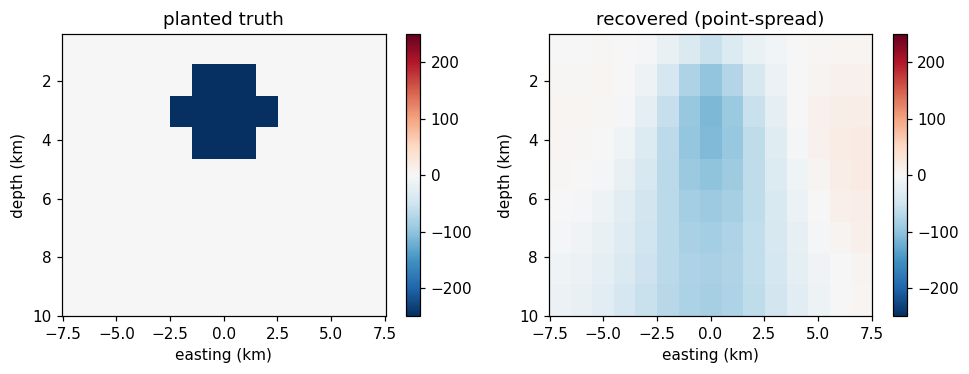

resolution test: the planted body recovers at the right place but DEEPER-SMEARED and weaker — the
survey resolves horizontal position well, absolute depth and amplitude poorly (the gravity ambiguity).


In [5]:
# plant a compact synthetic low-density sphere at 3 km depth, forward + noise, then invert with the same recipe
truth = np.zeros(Ncell)
ctr = np.array([0., 0., Z.mean()-3000.])
truth[np.linalg.norm(cells - ctr, axis=1) < 2200.] = -250.   # -250 kg/m3 blob
d_syn = G @ truth; d_syn = d_syn + 0.3*np.abs(d_syn).std()*np.random.RandomState(0).randn(len(d_syn))
rho_rec = (regularized_gauss_newton(lambda u: torch.as_tensor(G/w_dw[None,:]) @ u, d_syn, np.zeros(Ncell),
            noise=0.05*np.abs(d_syn).max()+0.2, beta=3e-3, roughness=R, n_iter=4, jac_every=99)[0]) / w_dw
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
for a, (t, m) in zip(ax, [('planted truth', truth), ('recovered (point-spread)', rho_rec)]):
    im = a.imshow(m.reshape(nx,ny,nz)[:, ny//2, :].T, origin='upper', extent=extent, aspect='auto', cmap='RdBu_r',
                  vmin=-250, vmax=250)
    a.set(title=t, xlabel='easting (km)', ylabel='depth (km)'); fig.colorbar(im, ax=a)
plt.tight_layout(); plt.show()
print('resolution test: the planted body recovers at the right place but DEEPER-SMEARED and weaker — the')
print('survey resolves horizontal position well, absolute depth and amplitude poorly (the gravity ambiguity).')

## Summary, limitations, and references

On a **real** Bouguer-gravity survey of an actively inflating volcano:

1. Newtonian gravity is a **linear** operator on the 3-D density model; its sensitivity decays with depth.
2. That decay makes the inverse problem **non-unique** and biases a naive inversion to the surface; **Li &
   Oldenburg depth weighting** removes the bias and lets the inversion place mass at depth — fitting the data
   *better* in the process.
3. The depth-weighted model fits ~90% of the anomaly with a coherent **low-density body a few kilometres
   beneath the lake** — consistent with the shallow silicic **magma reservoir** independently inferred from the
   surface uplift.
4. A **resolution test** turns the non-uniqueness into an honest statement: the survey constrains the body's
   *horizontal position* well but its *absolute depth and amplitude* poorly — so read the image accordingly.

**Limitations.** Gravity inversion is irreducibly **non-unique**; depth weighting and smoothness *choose* one
model among infinitely many that fit — the result is a hypothesis, not a measurement of depth. The point-mass
forward is approximate (the rectangular-prism formula of Nagy/Plouff is exact); a sparse 191-station survey
limits resolution; we removed only a planar regional trend; density contrast trades off with body volume.
Joint inversion with the surface-deformation (InSAR) and seismic data — which constrain depth far better —
is how Laguna del Maule is actually studied.

**References.**
- C. A. Miller et al. (2017), *Gravity changes at Laguna del Maule…* / Miller, Williams-Jones, Fournier,
  Witter (2016), *3D gravity inversion and thermodynamic modelling reveal properties of shallow silicic magma
  reservoir beneath Laguna del Maule, Chile*, Earth Planet. Sci. Lett. 459, 14–27.
- Y. Li & D. W. Oldenburg (1998), *3-D inversion of gravity data*, Geophysics 63(1), 109–119.
- R. J. Blakely (1995), *Potential Theory in Gravity and Magnetic Applications*, Cambridge Univ. Press.
- D. Nagy (1966), *The gravitational attraction of a right rectangular prism*, Geophysics 31(2), 362–371.

**Exercises.**
1. **Trade-off curve.** Sweep the depth-weighting exponent ν and the regularization β; plot recovered reservoir
   depth against data misfit — the non-uniqueness as a curve.
2. **Reservoir mass.** Integrate the density deficit over the body to estimate the mass deficit and, with an
   assumed melt density contrast, a magma volume; propagate the depth ambiguity into the estimate.
3. **Positivity / bounds.** Constrain the inversion to density contrasts in a physically plausible band and see
   how the image sharpens.
4. **Add magnetics.** Magnetic data (`magnetic_dipole_sensitivity`) sense a different property; couple the two
   with `cross_gradient`/`joint_inversion` and test whether the reservoir geometry sharpens.